![clothing_classification](clothing_classification.png)


Fashion Forward is a new AI-based e-commerce clothing retailer.
They want to use image classification to automatically categorize new product listings, making it easier for customers to find what they're looking for. It will also assist in inventory management by quickly sorting items.

As a data scientist tasked with implementing a garment classifier, your primary objective is to develop a machine learning model capable of accurately categorizing images of clothing items into distinct garment types such as shirts, trousers, shoes, etc.

In [129]:
# Run the cells below first

In [130]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy, Precision, Recall
import matplotlib.pyplot as plt

In [131]:
# Load datasets
from torchvision import datasets
import torchvision.transforms as transforms

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

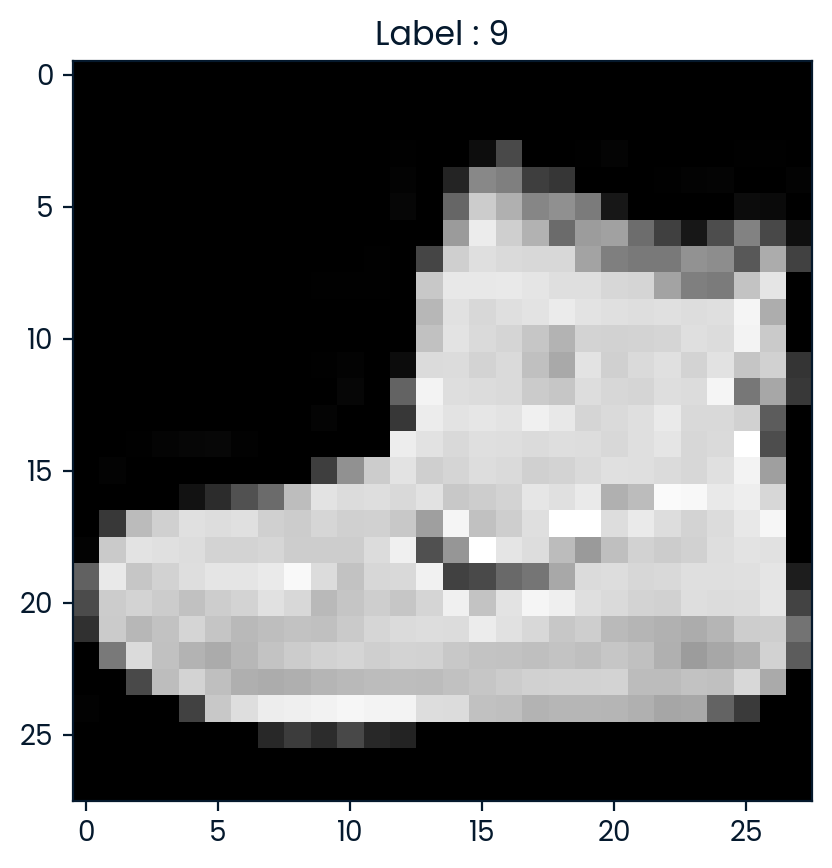

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [132]:
# Start coding here
# Use as many cells as you need
print(train_data)
print(train_data[0])
image,label = train_data[0]
print(image,label)
print(image.shape)

plt.imshow(image.squeeze(),cmap='gray')
plt.title(f'Label : {label}')
plt.show()

print(test_data.classes)


In [133]:
class Net(nn.Module):
    def __init__(self,input_channel,num_classes):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(input_channel,32,kernel_size=3,padding='same'),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(32,64,kernel_size=3,padding='same'),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),

            
            nn.Flatten(start_dim=1)            
        )
        self.classifier= nn.Linear(64*7*7,num_classes)
        # self.fc = nn.Linear(num_output_channels * (image_size//2)**2, num_classes)
    def forward(self,x):
       x= self.image_layer(x)
       x =self.classifier(x)
       return x
       

In [125]:
dataloader_train = DataLoader(train_data,shuffle=True,batch_size=32)
net = Net(1,10)
epochs = 2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr=0.001)
training_loss = 0
for epoch in range(epochs):
    for image,label in dataloader_train:
        optimizer.zero_grad()
        pred = net(image)
        loss = criterion(pred,label)
        training_loss += loss.item()
        loss.backward()
        optimizer.step()

        

In [126]:
print(training_loss/len(dataloader_train))

0.6563759340624015


In [127]:
dataloader_test = DataLoader(test_data,shuffle=False,batch_size=32)
net.eval()
test_loss=0

metric_recall = Recall(task='multiclass',num_classes=10,average=None)
metric_precision = Precision(task='multiclass',num_classes=10,average=None)
metric_acc = Accuracy(task='multiclass',num_classes=10)
predictions =[]
with torch.no_grad():
    for image,label in dataloader_test:
        output = net(image)
        pred = torch.argmax(output,dim=1)
        predictions.extend(pred.tolist())
        metric_recall(pred,label)
        metric_acc(pred,label)
        metric_precision(pred,label)
        
        
accuracy = metric_acc.compute().item()
precision = metric_precision.compute().tolist()
recall = metric_recall.compute().tolist()

print('Accuracy:', accuracy)
print('Precision (per class):', precision)
print('Recall (per class):', recall)

Accuracy: 0.9003999829292297
Precision (per class): [0.8531468510627747, 0.975271999835968, 0.8113383054733276, 0.8919722437858582, 0.838161826133728, 0.9858012199401855, 0.7522321343421936, 0.9385206699371338, 0.9750249981880188, 0.9744376540184021]
Recall (per class): [0.8539999723434448, 0.9860000014305115, 0.8730000257492065, 0.8999999761581421, 0.8389999866485596, 0.972000002861023, 0.6740000247955322, 0.9769999980926514, 0.9760000109672546, 0.953000009059906]
